# Quick HDF5 visualization after `add_key`

This notebook does a few quick sanity checks and makes a handful of plots from the merged event HDF5 file.

Set `H5_FILE` below to your merged file, for example:

```python
H5_FILE = "merged.evt.h5"
```

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

#H5_FILE = "input1_outputfile.evt.h5"   # change this if needed
H5_FILE = "/home/apaudel/NuGraph/data/data_40k/merged_large.evt.h5"
assert os.path.exists(H5_FILE), f"File not found: {H5_FILE}"
print("Using:", H5_FILE)
print("Size MB:", os.path.getsize(H5_FILE)/1024/1024)

Using: /home/apaudel/NuGraph/data/data_40k/merged_large.evt.h5
Size MB: 172.74236488342285


## 1. Quick HDF5 structure and `add_key` check

In [3]:
def print_tree(filename, max_items=120):
    n = 0
    with h5py.File(filename, "r") as f:
        def visit(name, obj):
            nonlocal n
            if n >= max_items:
                return
            if isinstance(obj, h5py.Dataset):
                print(f"/{name:50s} shape={obj.shape}, dtype={obj.dtype}")
            else:
                print(f"/{name:50s} Group")
            n += 1
        f.visititems(visit)

print_tree(H5_FILE)

print("\nSequencing metadata from add_key:")
with h5py.File(H5_FILE, "r") as f:
    seq_items = []
    def visit_seq(name, obj):
        if isinstance(obj, h5py.Dataset) and ("seq" in name or "seq_cnt" in name):
            seq_items.append((name, obj.shape))
    f.visititems(visit_seq)

for name, shape in seq_items:
    
    print(name, shape)

if len(seq_items) == 0:
    print("WARNING: no seq / seq_cnt datasets found.")

/edep_table                                         Group
/edep_table/energy                                  shape=(2893793, 1), dtype=float32
/edep_table/event_id                                shape=(2893793, 3), dtype=int32
/edep_table/event_id.seq_cnt                        shape=(38823, 2), dtype=int64
/edep_table/g4_id                                   shape=(2893793, 1), dtype=int32
/edep_table/hit_id                                  shape=(2893793, 1), dtype=int32
/edep_table/x_position                              shape=(2893793, 1), dtype=float32
/edep_table/y_position                              shape=(2893793, 1), dtype=float32
/edep_table/z_position                              shape=(2893793, 1), dtype=float32
/event_table                                        Group
/event_table/event_id                               shape=(40000, 3), dtype=int32
/event_table/event_id.seq_cnt                       shape=(40000, 2), dtype=int64
/event_table/is_cc                        

## 2. Small helper to load tables

In [4]:
def load_table(filename, group):
    cols = {}

    with h5py.File(filename, "r") as f:
        g = f[group]

        for name, ds in g.items():
            if not isinstance(ds, h5py.Dataset):
                continue

            # skip add_key event-count metadata
            if name.endswith("seq_cnt"):
                print("Skipping", group, name, ds.shape)
                continue

            arr = np.asarray(ds[:])

            if arr.ndim == 1:
                cols[name] = arr
            elif arr.ndim == 2 and arr.shape[1] == 1:
                cols[name] = arr[:, 0]
            elif arr.ndim == 2:
                for i in range(arr.shape[1]):
                    cols[f"{name}_{i}"] = arr[:, i]

    return pd.DataFrame(cols)

event_df = load_table(H5_FILE, "event_table")
hit_df = load_table(H5_FILE, "hit_table")
ophit_df = load_table(H5_FILE, "ophit_table")
opflash_df = load_table(H5_FILE, "opflash_table")
opflashsumpe_df = load_table(H5_FILE, "opflashsumpe_table")

print("event_table:", event_df.shape)
print("hit_table:", hit_df.shape)
print("ophit_table:", ophit_df.shape)
print("opflash_table:", opflash_df.shape)
print("opflashsumpe_table:", opflashsumpe_df.shape)

event_df.head()

Skipping event_table event_id.seq_cnt (40000, 2)
Skipping hit_table event_id.seq_cnt (38823, 2)
Skipping ophit_table event_id.seq_cnt (39717, 2)
Skipping opflash_table event_id.seq_cnt (38944, 2)
Skipping opflashsumpe_table event_id.seq_cnt (38944, 2)
event_table: (40000, 11)
hit_table: (1303241, 13)
ophit_table: (9093765, 15)
opflash_table: (55105, 14)
opflashsumpe_table: (2926393, 7)


,event_id_0,event_id_1,event_id_2,is_cc,is_es,lep_energy,nu_dir_0,nu_dir_1,nu_dir_2,nu_energy,nu_pdg
0,20000001,1,1,1,0,0.033674,-0.237873,-0.739977,0.629167,0.049219,12
1,20000001,1,2,1,0,0.039151,-0.172280,0.981659,0.081646,0.044534,12
2,20000001,1,3,1,0,0.029817,-0.128430,-0.983221,0.129549,0.033132,12
3,20000001,1,4,1,0,0.042122,0.959107,-0.099055,-0.265146,0.057592,12
4,20000001,1,5,1,0,0.037085,-0.634388,-0.195043,-0.748004,0.040858,12


## 3. Plot: row counts per table

,table,rows
0,event,40000
1,hit,1303241
2,ophit,9093765
3,opflash,55105
4,opflashsumpe,2926393


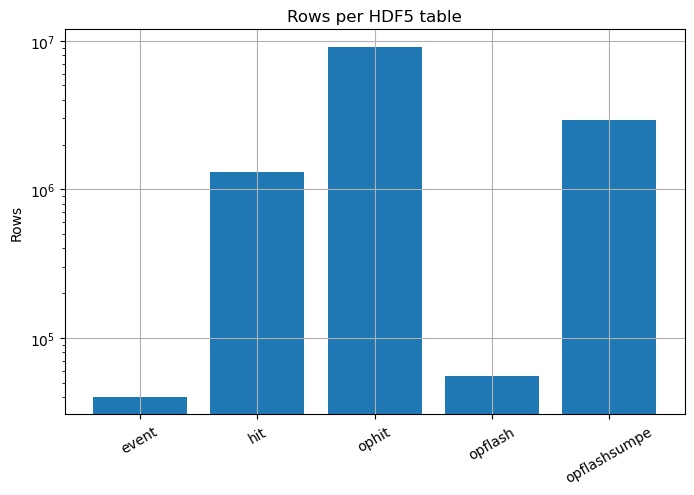

In [5]:
table_counts = pd.DataFrame({
    "table": ["event", "hit", "ophit", "opflash", "opflashsumpe"],
    "rows": [len(event_df), len(hit_df), len(ophit_df), len(opflash_df), len(opflashsumpe_df)]
})

display(table_counts)

plt.figure()
plt.bar(table_counts["table"], table_counts["rows"])
plt.yscale("log")
plt.ylabel("Rows")
plt.title("Rows per HDF5 table")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

## 4. Plot: event-level variables

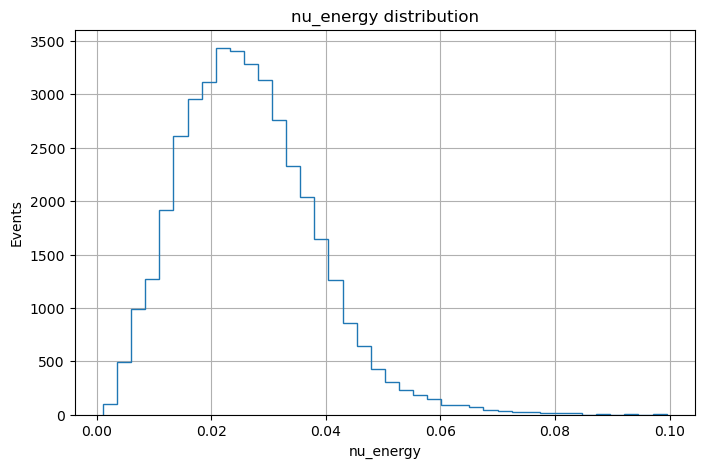

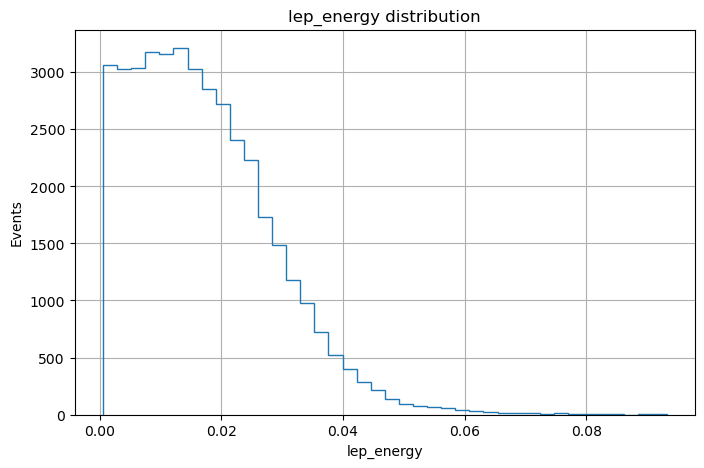


is_es counts:
is_es
0    20000
1    20000
Name: count, dtype: int64

is_cc counts:
is_cc
0    20000
1    20000
Name: count, dtype: int64

nu_pdg counts:
nu_pdg
12    40000
Name: count, dtype: int64


In [6]:
for col in ["nu_energy", "lep_energy"]:
    if col in event_df.columns:
        plt.figure()
        plt.hist(event_df[col], bins=40, histtype="step")
        plt.xlabel(col)
        plt.ylabel("Events")
        plt.title(f"{col} distribution")
        plt.grid(True)
        plt.show()

for col in ["is_es", "is_cc", "nu_pdg"]:
    if col in event_df.columns:
        print(f"\n{col} counts:")
        print(event_df[col].value_counts().sort_index())

## 5. Plot: TPC hits, wire vs time

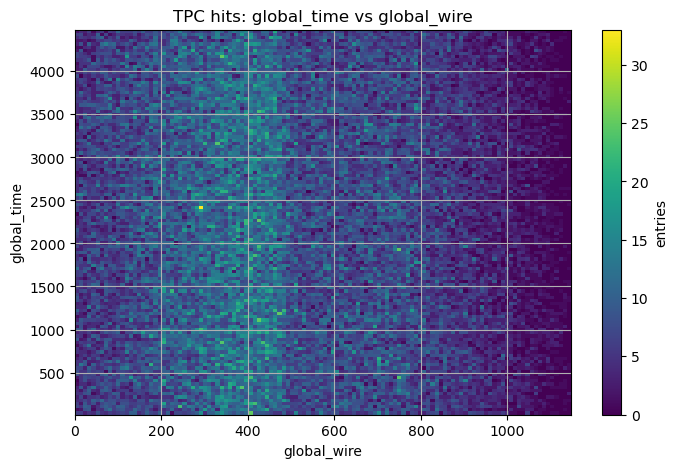

In [7]:
# Use all hits unless very large, then randomly downsample for speed
df = hit_df.copy()
if len(df) > 100_000:
    df = df.sample(100_000, random_state=1)

if "global_wire" in df.columns and "global_time" in df.columns:
    plt.figure()
    plt.hist2d(df["global_wire"], df["global_time"], bins=120)
    plt.colorbar(label="entries")
    plt.xlabel("global_wire")
    plt.ylabel("global_time")
    plt.title("TPC hits: global_time vs global_wire")
    plt.grid(True)
    plt.show()
else:
    print("global_wire/global_time not found in hit_table")

## 6. Plot: OpHit PE and channel activity

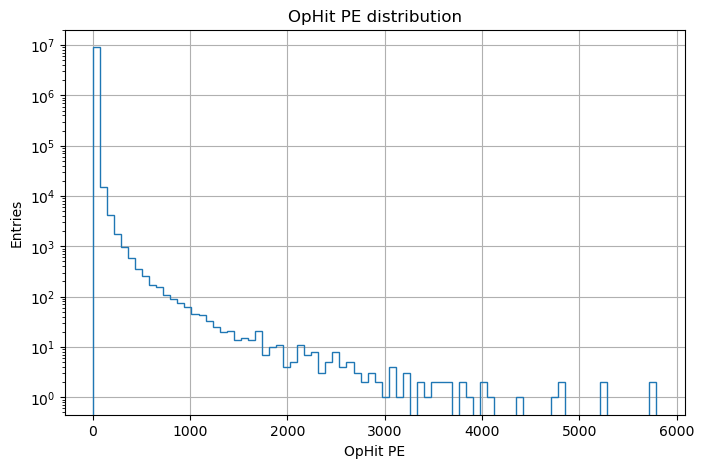

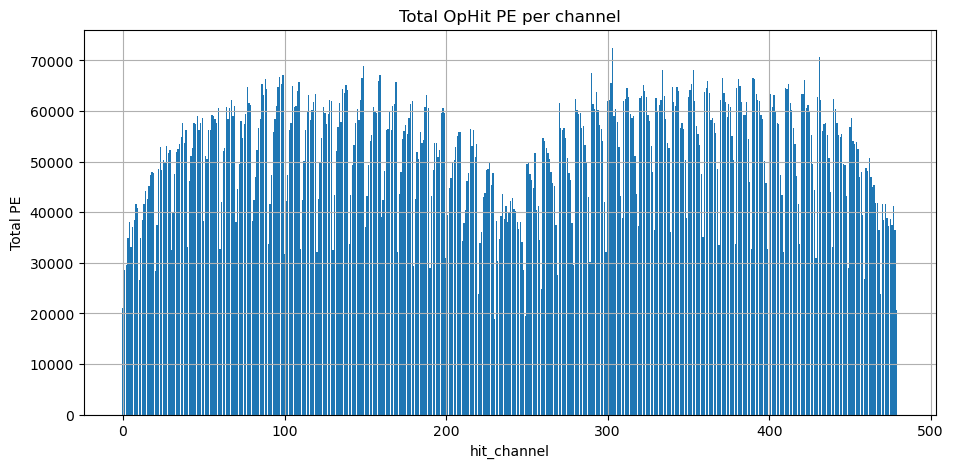

In [8]:
if "pe" in ophit_df.columns:
    plt.figure()
    plt.hist(ophit_df["pe"], bins=80, histtype="step")
    plt.yscale("log")
    plt.xlabel("OpHit PE")
    plt.ylabel("Entries")
    plt.title("OpHit PE distribution")
    plt.grid(True)
    plt.show()

if "hit_channel" in ophit_df.columns and "pe" in ophit_df.columns:
    pe_by_channel = ophit_df.groupby("hit_channel")["pe"].sum().reset_index()

    plt.figure(figsize=(11, 5))
    plt.bar(pe_by_channel["hit_channel"], pe_by_channel["pe"])
    plt.xlabel("hit_channel")
    plt.ylabel("Total PE")
    plt.title("Total OpHit PE per channel")
    plt.grid(True)
    plt.show()

## 7. Plot: OpFlash Y-Z map and total PE

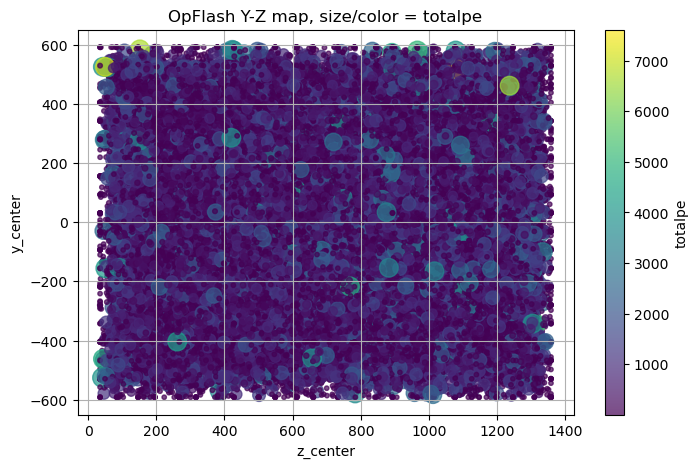

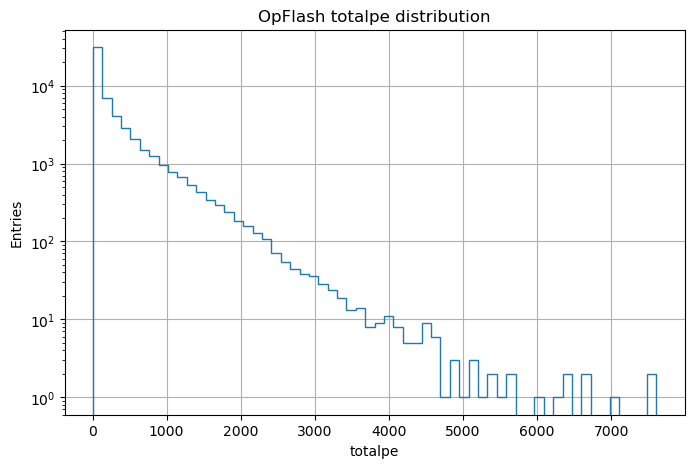

In [9]:
if all(c in opflash_df.columns for c in ["z_center", "y_center", "totalpe"]):
    df = opflash_df[opflash_df["totalpe"] > 0].copy()

    size = 10 + 120 * df["totalpe"] / max(df["totalpe"].quantile(0.99), 1e-9)
    size = np.clip(size, 10, 180)

    plt.figure()
    sc = plt.scatter(df["z_center"], df["y_center"], c=df["totalpe"], s=size, alpha=0.7)
    plt.colorbar(sc, label="totalpe")
    plt.xlabel("z_center")
    plt.ylabel("y_center")
    plt.title("OpFlash Y-Z map, size/color = totalpe")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.hist(df["totalpe"], bins=60, histtype="step")
    plt.yscale("log")
    plt.xlabel("totalpe")
    plt.ylabel("Entries")
    plt.title("OpFlash totalpe distribution")
    plt.grid(True)
    plt.show()
else:
    print("z_center/y_center/totalpe not found in opflash_table")

## 8. Plot: OpFlashSumPE per channel

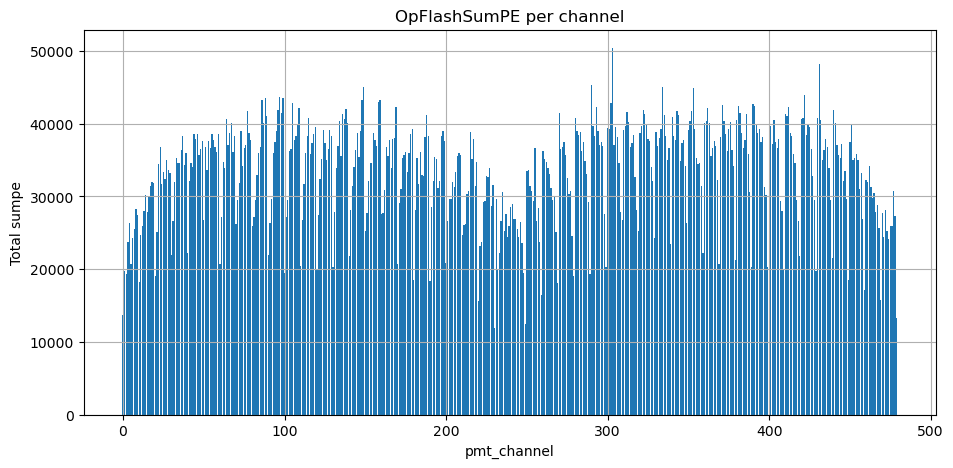

In [10]:
if "pmt_channel" in opflashsumpe_df.columns and "sumpe" in opflashsumpe_df.columns:
    sumpe_by_channel = opflashsumpe_df.groupby("pmt_channel")["sumpe"].sum().reset_index()

    plt.figure(figsize=(11, 5))
    plt.bar(sumpe_by_channel["pmt_channel"], sumpe_by_channel["sumpe"])
    plt.xlabel("pmt_channel")
    plt.ylabel("Total sumpe")
    plt.title("OpFlashSumPE per channel")
    plt.grid(True)
    plt.show()
else:
    print("pmt_channel/sumpe not found in opflashsumpe_table")

## 9. One-line custom plots

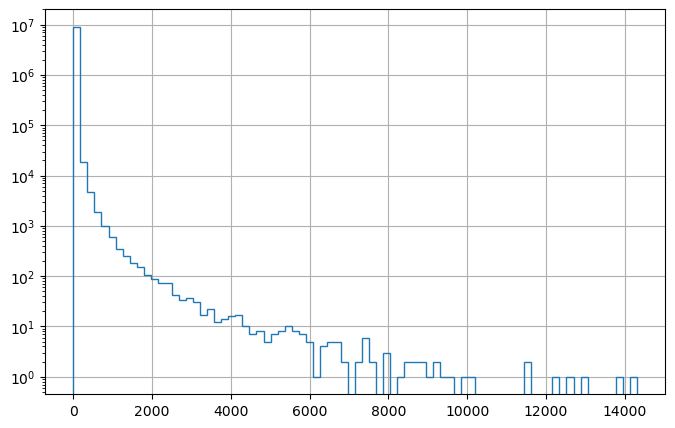

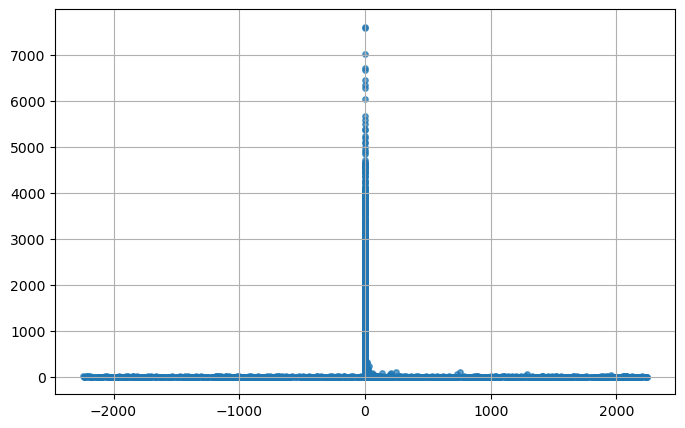

In [11]:
# Quick examples you can modify:

plt.figure(); plt.hist(ophit_df["amplitude"], bins=80, histtype="step"); plt.yscale("log"); plt.show()
#plt.figure(); plt.hist2d(ophit_df["amplitude"], ophit_df["pe"], bins=100); plt.xlim(0, ophit_df["amplitude"].quantile(0.99)); plt.ylim(0, ophit_df["pe"].quantile(0.99)); plt.colorbar(); plt.show()
plt.figure(); plt.scatter(opflash_df["time"], opflash_df["totalpe"], s=15, alpha=0.7); plt.show()

In [12]:
# Check label columns
event_df[["is_es", "is_cc"]].head()

,is_es,is_cc
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [13]:
event_df[["is_es", "is_cc"]]

,is_es,is_cc
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
39995,1,0
39996,1,0
39997,1,0
39998,1,0
